# Attribute Computation and Filtering

This notebook shows how to compute node attributes on weighted morphological trees and use those attributes to build simple connected filters. It uses the same image to compare a tree of shapes, a max-tree, and a min-tree.


In [19]:
import numpy as np
import mmcfilters
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv

import mtviz as viz
import mmcfilters



## Load and inspect the input image

The examples use a grayscale test image. The image values define the altitude of the component tree nodes, while the grid adjacency controls which pixels may belong to the same connected component.


In [20]:
input_image = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)
#input_image = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
#input_image = cv.imread("../dat/cable.png", cv.IMREAD_GRAYSCALE)
#input_image = cv.imread("../dat/images/peppers_gray.tif", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = input_image.shape



## Build a weighted tree of shapes and compute attributes

`computeAttributes` evaluates several attribute calculators in one pass and returns a table indexed by node. The notebook keeps the attribute names in `attribute_indices` so later cells can select columns without hard-coded positions.


In [21]:
AT= mmcfilters.Attribute.Type
tree = mmcfilters.WeightedMorphologicalTree.createTreeOfShapes(input_image, interpolation=mmcfilters.ToSInterpolation.SelfDual)
mmcfilters.Attribute.computeAttributes(tree, [AT.AREA, AT.VOLUME, AT.BOX_HEIGHT])

({'AREA': 0, 'VOLUME': 1, 'BOX_HEIGHT': 2},
 array([[2.5000000e+05, 3.2991866e+07, 5.0000000e+02],
        [3.3830000e+04, 3.7804140e+06, 2.0000000e+02],
        [1.1156400e+05, 1.0283698e+07, 4.7800000e+02],
        [2.4413000e+04, 2.4757900e+06, 2.8100000e+02],
        [1.6137000e+04, 2.2688160e+06, 1.7500000e+02],
        [8.9290000e+03, 6.4288800e+05, 1.1400000e+02],
        [1.5485000e+04, 8.3619000e+05, 1.8300000e+02],
        [3.0180000e+03, 1.5665700e+05, 6.8000000e+01],
        [4.2100000e+02, 1.6419000e+04, 2.3000000e+01],
        [6.8210000e+03, 2.5919800e+05, 9.7000000e+01]], dtype=float32))

In [22]:
import pandas as pd
ok = True
selected_attributes = [
    mmcfilters.Attribute.Type.AREA,
    mmcfilters.Attribute.Type.INERTIA,
    mmcfilters.Attribute.Type.BOX_HEIGHT,
]
trainset = ["../dat/imgTeste.png", "../dat/imgObjetos.png", "../dat/cable.png"]
for i in range(len(trainset)):
    img = cv.imread(trainset[i], cv.IMREAD_GRAYSCALE)
    (img_rows, img_cols) = img.shape
    tree = mmcfilters.WeightedMorphologicalTree.createTreeOfShapes(input_image, interpolation=mmcfilters.ToSInterpolation.SelfDual)
    features, attribute_matrix = mmcfilters.Attribute.computeAttributes(tree, selected_attributes)

    df2 = pd.DataFrame(attribute_matrix, columns=list(features.keys()))
    if len(df2[df2.isna().any(axis=1)]) > 0:
        print(i, df2[df2.isna().any(axis=1)])
        ok = False
if ok:
    print("Attributes verified, no NaN values found in the selected subset.")

Attributes verified, no NaN values found in the selected subset.


## Compare tree families

The same attribute set is computed on a max-tree, a min-tree, and a tree of shapes. This makes it easier to check whether an attribute behaves consistently across different tree topologies.


In [23]:
max_tree = mmcfilters.WeightedMorphologicalTree.createMaxTree(input_image, radius=1.5)
min_tree = mmcfilters.WeightedMorphologicalTree.createMinTree(input_image, radius=1.5)
tos = mmcfilters.WeightedMorphologicalTree.createTreeOfShapes(input_image, interpolation=mmcfilters.ToSInterpolation.SelfDual)
tos_4c8c = mmcfilters.WeightedMorphologicalTree.createTreeOfShapes(input_image, interpolation=mmcfilters.ToSInterpolation.Min4cMax8c)

max_tree_filter = mmcfilters.AttributeFilters(max_tree)
min_tree_filter = mmcfilters.AttributeFilters(min_tree)
tos_filter = mmcfilters.AttributeFilters(tos)
tos_4c8c_filter = mmcfilters.AttributeFilters(tos_4c8c)

selected_attributes = [
    mmcfilters.Attribute.Type.AREA,
    mmcfilters.Attribute.Type.INERTIA,
    mmcfilters.Attribute.Type.BOX_HEIGHT,
]
attribute_indices, max_tree_attribute_matrix = mmcfilters.Attribute.computeAttributes(max_tree, selected_attributes)
attribute_indices, min_tree_attribute_matrix = mmcfilters.Attribute.computeAttributes(min_tree, selected_attributes)
attribute_indices, tos_attribute_matrix = mmcfilters.Attribute.computeAttributes(tos, selected_attributes)
attribute_indices, tos_4c8c_attribute_matrix = mmcfilters.Attribute.computeAttributes(tos_4c8c, selected_attributes)
attribute_indices

{'AREA': 0, 'BOX_HEIGHT': 1, 'INERTIA': 2}

## Inspect nodes and contours

The tree printer summarizes the parent-child structure and the selected node attributes. The contour helper below is used to visualize which image regions are affected by later filters.


In [24]:
pt = viz.PrintTree(lambda n: tos.getChildren(n), lambda n: f"id:{n}: altitude: {tos.getAltitude(n)}")
pt(tos.getRoot())

                             id:0: altitude: 203
         ┌────────────────────────────┴┬────────────────────────────┐
id:1: altitude: 126            id:2: altitude: 78           id:6: altitude: 54
         |                   ┌─────────┴─────────┐                            
 id:5: altitude: 72 id:3: altitude: 126 id:4: altitude: 161                   
                             |                   |                            
                     id:9: altitude: 38  id:7: altitude: 54                   
                                                 |                            
                                         id:8: altitude: 39


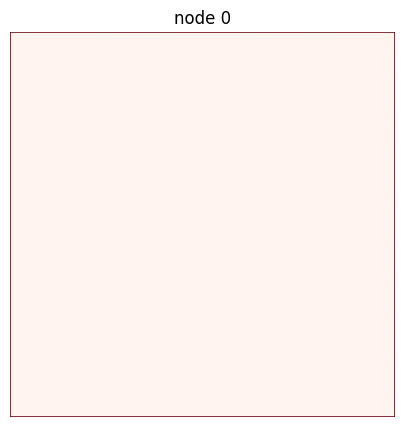

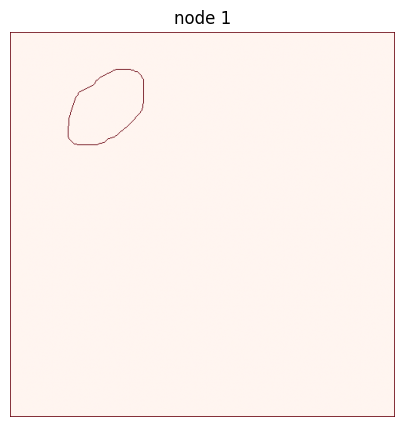

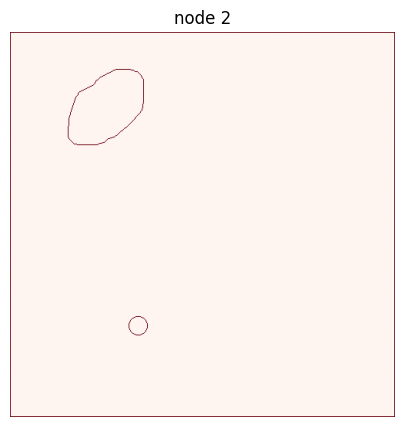

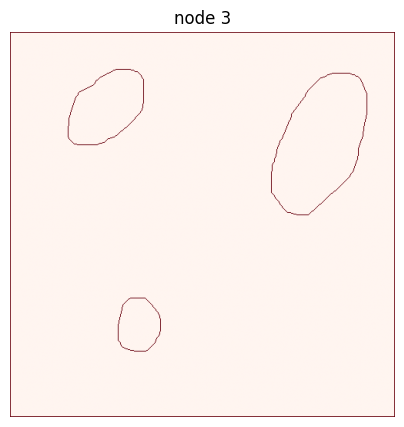

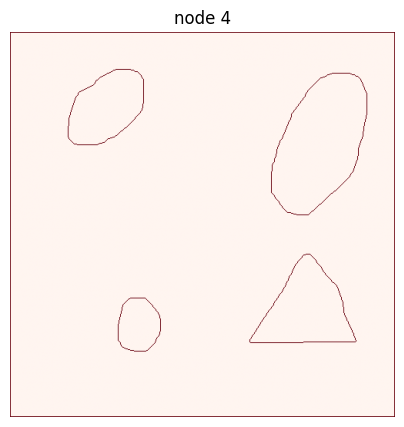

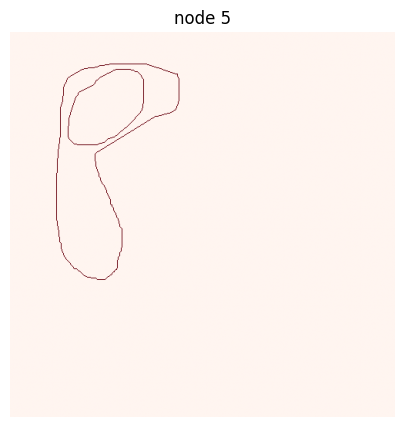

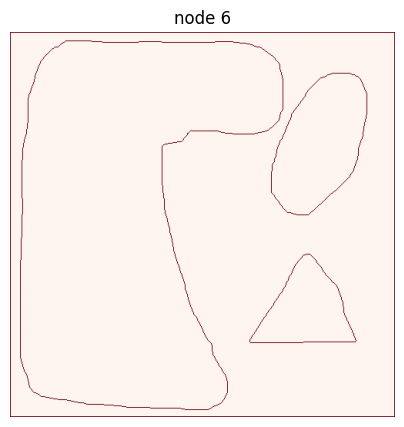

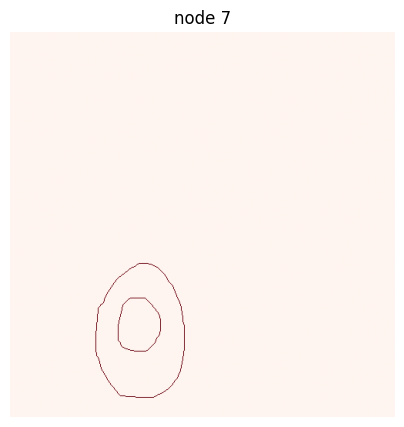

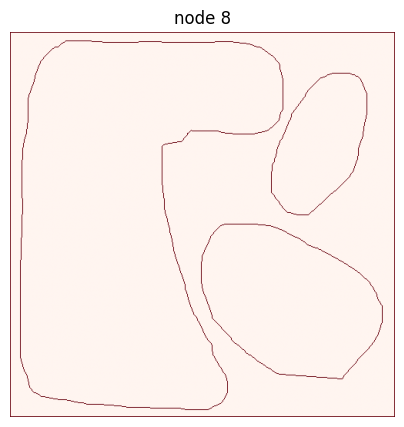

In [25]:
def plot_contours(pixels, node_id, num_rows, num_cols):
    contour_image = np.zeros((num_rows, num_cols), dtype=np.uint8)

    for p in pixels:
        row = p // num_cols
        col = p % num_cols
        contour_image[row, col] = 255

    plt.figure(figsize=(5, 5))
    plt.imshow(contour_image, cmap='Reds')
    plt.title(f"node {node_id}")
    plt.axis('off')
    plt.show()

tree_contours = mmcfilters.ContourComputation.extraction(max_tree)
area_col = attribute_indices['AREA']
for nodeId, contour in tree_contours.contoursByNode():
    if max_tree_attribute_matrix[nodeId, area_col] > 100:
        plot_contours(contour, nodeId, num_rows, num_cols)

## Filter by individual attributes

The following cells apply attribute thresholds directly to the tree. Area and inertia highlight different structures, so comparing their outputs helps validate both the attribute values and the reconstruction step.


Text(0.5, 1.0, 'attribute filter (tos)')

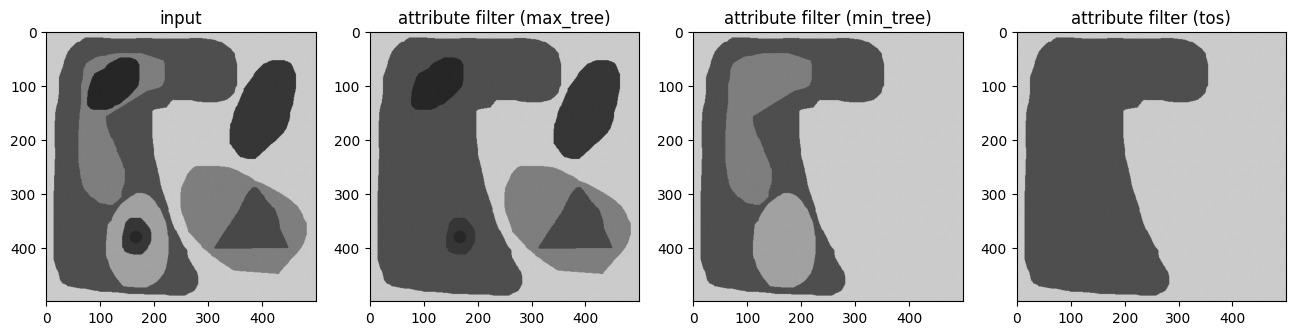

In [26]:
area_col = attribute_indices['AREA']
threshold = (num_rows*num_cols) *0.25

max_tree_area = max_tree_attribute_matrix[:, area_col]
min_tree_area = min_tree_attribute_matrix[:, area_col]
tos_area = tos_attribute_matrix[:, area_col]

max_tree_filtered_image = max_tree_filter.filteringDirectRule(max_tree_area > threshold)
min_tree_filtered_image = min_tree_filter.filteringDirectRule(min_tree_area > threshold)
tos_filtered_image = tos_filter.filteringDirectRule(tos_area > threshold)

plt.subplot(1,4, 1)
plt.imshow(input_image, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(max_tree_filtered_image, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (max_tree)')

plt.subplot(1,4, 3)
plt.imshow(min_tree_filtered_image, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (min_tree)')

plt.subplot(1,4, 4)
plt.imshow(tos_filtered_image, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

Text(0.5, 1.0, 'attribute filter (tos)')

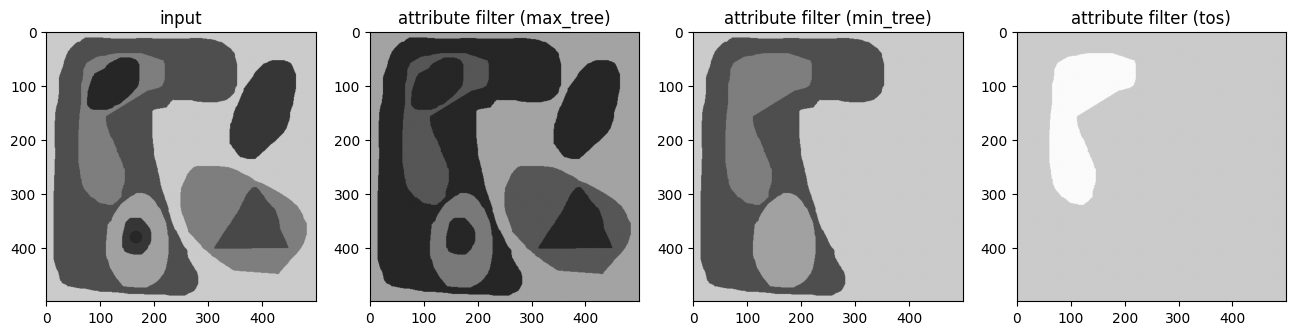

In [27]:
inertia_col = attribute_indices['INERTIA']
threshold = 0.2

max_tree_inertia = max_tree_attribute_matrix[:, inertia_col]
min_tree_inertia = min_tree_attribute_matrix[:, inertia_col]
tos_inertia = tos_attribute_matrix[:, inertia_col]

max_tree_filtered_image = max_tree_filter.filteringSubtractiveRule(max_tree_inertia > threshold)
min_tree_filtered_image = min_tree_filter.filteringSubtractiveRule(min_tree_inertia > threshold)
tos_filtered_image = tos_filter.filteringSubtractiveRule(tos_inertia > threshold)

plt.subplot(1,4, 1)
plt.imshow(input_image, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(max_tree_filtered_image, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (max_tree)')

plt.subplot(1,4, 3)
plt.imshow(min_tree_filtered_image, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (min_tree)')

plt.subplot(1,4, 4)
plt.imshow(tos_filtered_image, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')